# Vietnamese Emotion Classification Model

This notebook builds and evaluates multiple Vietnamese NLP models for emotion classification using the NEU-ESC dataset.

## Models to Compare:
1. **PhoBERT** - State-of-the-art Vietnamese BERT model
2. **XLM-RoBERTa** - Multilingual transformer model
3. **mBERT** - Multilingual BERT
4. **ViT5** - Vietnamese T5 model (optional)

## Workflow:
1. Data Loading and Exploration
2. Data Preprocessing
3. Model Training (all models with sample data)
4. Model Comparison and Selection
5. Full Training with Best Model
6. Evaluation and Testing
7. Results and Metrics Analysis


## 1. Install Required Libraries

Installing all necessary libraries for Vietnamese NLP models including transformers, datasets, and evaluation metrics.


In [1]:
%pip install -q transformers datasets torch torchvision torchaudio scikit-learn pandas numpy matplotlib seaborn accelerate sentencepiece openpyxl



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Import Libraries

Import all necessary libraries for data processing, model training, and evaluation.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check device - prioritize MPS for Mac
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"Using device: {device} (Metal Performance Shaders)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using device: {device}")
else:
    device = torch.device('cpu')
    print(f"Using device: {device}")
    
# Set MPS fallback behavior for unsupported operations
if device.type == 'mps':
    os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
    print("MPS fallback enabled for unsupported operations")
    
    # Memory management function for MPS
    def clear_mps_memory():
        """Clear MPS cache to free up memory"""
        import gc
        gc.collect()
        torch.mps.empty_cache()
    
    print("✓ MPS memory management functions loaded")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps (Metal Performance Shaders)
MPS fallback enabled for unsupported operations


## 3. Load Dataset

Loading the Vietnamese emotion dataset from local Excel files.
The dataset is split into train, validation, and test sets with emotion labels and corresponding sentences.


In [3]:
# Load the datasets from local Excel files
data_dir = '/Users/giahuy/Documents/GitHub/topicmodeling/data'

# Load train, validation, and test sets
train_df = pd.read_excel(os.path.join(data_dir, 'train_nor_811.xlsx'))
val_df = pd.read_excel(os.path.join(data_dir, 'valid_nor_811.xlsx'))
test_df = pd.read_excel(os.path.join(data_dir, 'test_nor_811.xlsx'))

print("Datasets loaded successfully!")
print(f"\nTrain set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"\nTrain set columns: {train_df.columns.tolist()}")
print(f"\nFirst 5 records from training set:")
print(train_df.head())

# Drop the first column (ID column) as it's not necessary for training
train_df = train_df.drop(train_df.columns[0], axis=1)
val_df = val_df.drop(val_df.columns[0], axis=1)
test_df = test_df.drop(test_df.columns[0], axis=1)

print("First column (ID) dropped from all datasets")
print(f"\nUpdated Train set shape: {train_df.shape}")
print(f"Updated Validation set shape: {val_df.shape}")
print(f"Updated Test set shape: {test_df.shape}")

print(f"\nUpdated Train set columns: {train_df.columns.tolist()}")
print(f"\nFirst 5 records from training set after dropping ID column:")
print(train_df.head())



Datasets loaded successfully!

Train set shape: (5548, 3)
Validation set shape: (686, 3)
Test set shape: (693, 3)

Train set columns: ['Unnamed: 0', 'Emotion', 'Sentence']

First 5 records from training set:
   Unnamed: 0    Emotion                                           Sentence
0         188      Other              cho mình xin bài nhạc tên là gì với ạ
1         166    Disgust  cho đáng đời con quỷ . về nhà lôi con nhà mày ...
2        1345    Disgust  lo học đi . yêu đương lol gì hay lại thích học...
3         316  Enjoyment    uớc gì sau này về già vẫn có thể như cụ này :))
4        1225  Enjoyment  mỗi lần có video của con là cứ coi đi coi lại ...
First column (ID) dropped from all datasets

Updated Train set shape: (5548, 2)
Updated Validation set shape: (686, 2)
Updated Test set shape: (693, 2)

Updated Train set columns: ['Emotion', 'Sentence']

First 5 records from training set after dropping ID column:
     Emotion                                           Sentence
0      

## 4. Exploratory Data Analysis

Let's examine the dataset structure, emotion distribution, and sample texts.


In [4]:
# Standardize column names (first column = emotion/label, second column = text/sentence)
# Rename columns for consistency
train_df.columns = ['label', 'text']
val_df.columns = ['label', 'text']
test_df.columns = ['label', 'text']

print("Column names standardized to: ['label', 'text']")
print(f"\nDataset info (Training set):")
print(train_df.info())
print("\nSample data:")
print(train_df.head(10))


Column names standardized to: ['label', 'text']

Dataset info (Training set):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5548 entries, 0 to 5547
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5548 non-null   object
 1   text    5548 non-null   object
dtypes: object(2)
memory usage: 86.8+ KB
None

Sample data:
       label                                               text
0      Other              cho mình xin bài nhạc tên là gì với ạ
1    Disgust  cho đáng đời con quỷ . về nhà lôi con nhà mày ...
2    Disgust  lo học đi . yêu đương lol gì hay lại thích học...
3  Enjoyment    uớc gì sau này về già vẫn có thể như cụ này :))
4  Enjoyment  mỗi lần có video của con là cứ coi đi coi lại ...
5      Anger  thằng kia sao mày bắt vợ với bồ tao dọn thế ki...
6      Other                      một lí do trog muôn vàn lí do
7   Surprise           thật hay đùa ác vậy . không thể tin được
8      Anger  ko phải con mình , mà 

Emotion distribution in training set:
label
Enjoyment    1558
Disgust      1071
Other        1021
Sadness       947
Anger         391
Fear          318
Surprise      242
Name: count, dtype: int64


Emotion distribution in validation set:
label
Enjoyment    214
Other        141
Disgust      135
Sadness       86
Anger         49
Fear          31
Surprise      30
Name: count, dtype: int64


Emotion distribution in test set:
label
Enjoyment    193
Disgust      132
Other        129
Sadness      116
Fear          46
Anger         40
Surprise      37
Name: count, dtype: int64



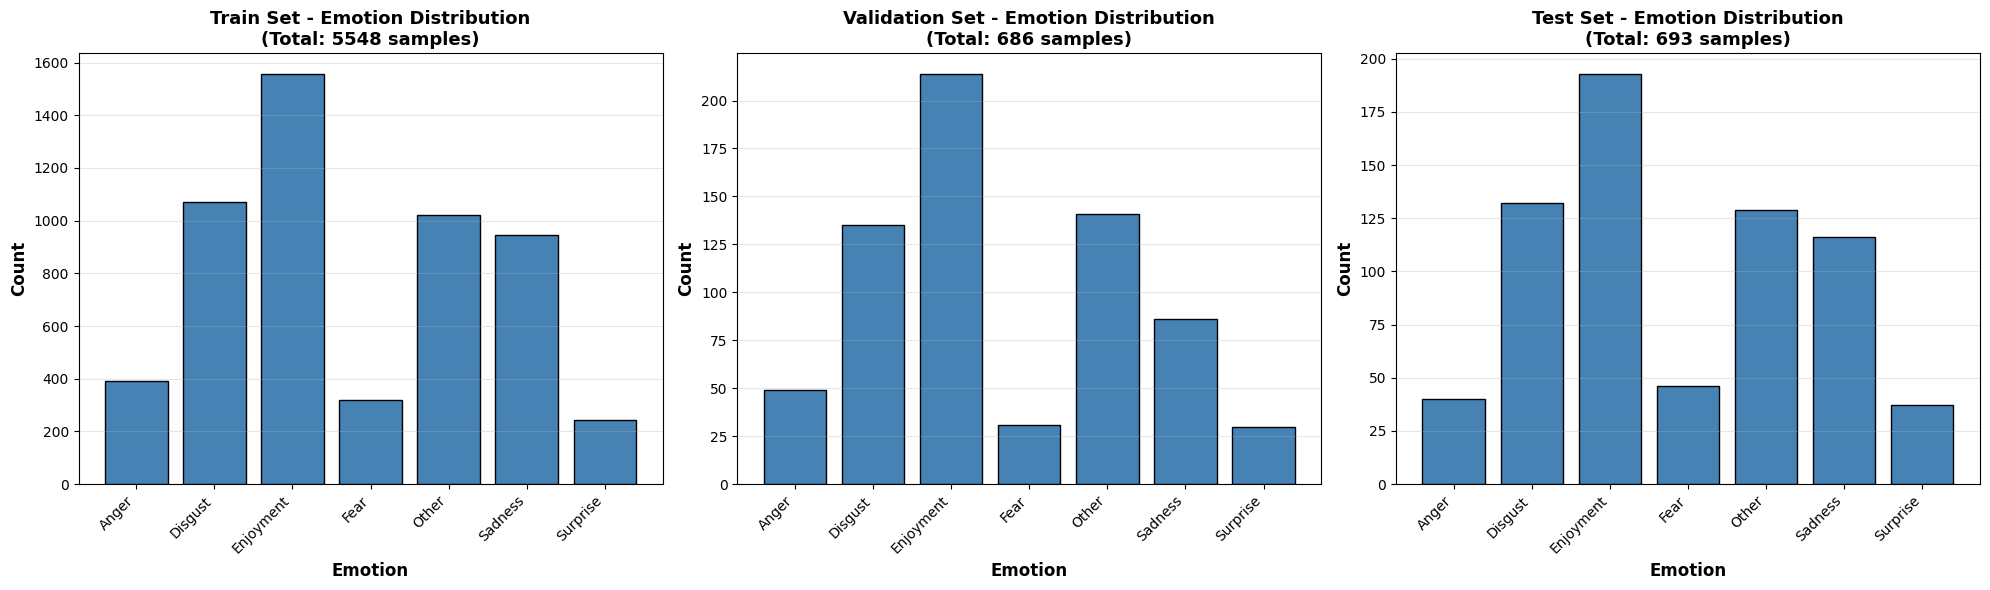

In [5]:
# Check emotion distribution across all splits
print("Emotion distribution in training set:")
print(train_df['label'].value_counts())
print("\n" + "="*80)

print("\nEmotion distribution in validation set:")
print(val_df['label'].value_counts())
print("\n" + "="*80)

print("\nEmotion distribution in test set:")
print(test_df['label'].value_counts())
print("\n" + "="*80)

# Visualize emotion distribution across all splits
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (df_split, title) in enumerate([(train_df, 'Train'), (val_df, 'Validation'), (test_df, 'Test')]):
    emotion_counts = df_split['label'].value_counts().sort_index()
    axes[idx].bar(range(len(emotion_counts)), emotion_counts.values, color='steelblue', edgecolor='black')
    axes[idx].set_xlabel('Emotion', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{title} Set - Emotion Distribution\n(Total: {len(df_split)} samples)', 
                       fontsize=13, fontweight='bold')
    axes[idx].set_xticks(range(len(emotion_counts)))
    axes[idx].set_xticklabels(emotion_counts.index, rotation=45, ha='right')
    axes[idx].grid(axis='y', alpha=0.3)
    
plt.tight_layout()
plt.show()


In [6]:
# Show sample texts for each emotion from training set
print("Sample texts for each emotion (from training set):\n")
print("="*80)

for emotion in sorted(train_df['label'].unique()):
    samples = train_df[train_df['label'] == emotion].head(2)  # Show 2 examples per emotion
    print(f"\nEmotion: {emotion}")
    print("-" * 80)
    for idx, row in samples.iterrows():
        print(f"  Example: {row['text']}")
    print("-" * 80)


Sample texts for each emotion (from training set):


Emotion: Anger
--------------------------------------------------------------------------------
  Example: thằng kia sao mày bắt vợ với bồ tao dọn thế kia . nhà mày ở đâu tao đến thịt mày chết
  Example: ko phải con mình , mà xem còn thấy đau như vậy huống gì người trong cuộc . thật là phẫn nộ mà . cơ quan chức năng làm việc quá chậm trễ , đến giờ mà vẫn chưa tìm ra người chịu trách nhiệm . 😠😠😠😠😠😠
--------------------------------------------------------------------------------

Emotion: Disgust
--------------------------------------------------------------------------------
  Example: cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
  Example: lo học đi . yêu đương lol gì hay lại thích học sinh học
--------------------------------------------------------------------------------

Emotion: Enjoyment
--------------------------------------------------------------------------------
  Example: uớc gì sau này về già vẫn có thể như

## 5. Data Preprocessing

Prepare the data for model training by creating label mappings and converting to HuggingFace dataset format.


In [7]:
# Clean the data - remove any missing values
train_df = train_df.dropna(subset=['text', 'label'])
val_df = val_df.dropna(subset=['text', 'label'])
test_df = test_df.dropna(subset=['text', 'label'])

# Remove any potential whitespace
train_df['text'] = train_df['text'].astype(str).str.strip()
train_df['label'] = train_df['label'].astype(str).str.strip()
val_df['text'] = val_df['text'].astype(str).str.strip()
val_df['label'] = val_df['label'].astype(str).str.strip()
test_df['text'] = test_df['text'].astype(str).str.strip()
test_df['label'] = test_df['label'].astype(str).str.strip()

print("Data cleaned successfully!")
print(f"\nFinal dataset sizes:")
print(f"  Train set: {len(train_df)} samples")
print(f"  Validation set: {len(val_df)} samples")
print(f"  Test set: {len(test_df)} samples")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df)} samples")


Data cleaned successfully!

Final dataset sizes:
  Train set: 5548 samples
  Validation set: 686 samples
  Test set: 693 samples
  Total: 6927 samples


In [8]:
# Create label mappings
unique_labels = sorted(train_df['label'].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"Number of emotion classes: {len(unique_labels)}")
print(f"\nLabel mappings:")
for label, idx in label2id.items():
    print(f"  {label}: {idx}")

# Add numeric labels to dataframes
train_df['labels'] = train_df['label'].map(label2id)
val_df['labels'] = val_df['label'].map(label2id)
test_df['labels'] = test_df['label'].map(label2id)

# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(train_df[['text', 'labels']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['text', 'labels']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['text', 'labels']].reset_index(drop=True))

# Create a smaller sample for quick model comparison (20% of train data)
sample_size = int(0.2 * len(train_df))
train_sample_df = train_df.sample(n=sample_size, random_state=SEED)
train_sample_dataset = Dataset.from_pandas(train_sample_df[['text', 'labels']].reset_index(drop=True))

print(f"\nFull training set: {len(train_dataset)} samples")
print(f"Sample training set for comparison: {len(train_sample_dataset)} samples")
print(f"Validation set: {len(val_dataset)} samples")
print(f"Test set: {len(test_dataset)} samples")


Number of emotion classes: 7

Label mappings:
  Anger: 0
  Disgust: 1
  Enjoyment: 2
  Fear: 3
  Other: 4
  Sadness: 5
  Surprise: 6

Full training set: 5548 samples
Sample training set for comparison: 1109 samples
Validation set: 686 samples
Test set: 693 samples


## 6. Define Model Configurations

Configure the Vietnamese NLP models to be compared


In [9]:
# Define models to compare
models_config = {
    'PhoBERT': 'vinai/phobert-base',
    'XLM-RoBERTa': 'xlm-roberta-base',
    'mBERT': 'bert-base-multilingual-cased'
}

print("Models to be compared:")
for name, model_id in models_config.items():
    print(f"  - {name}: {model_id}")


Models to be compared:
  - PhoBERT: vinai/phobert-base
  - XLM-RoBERTa: xlm-roberta-base
  - mBERT: bert-base-multilingual-cased


## 7. Helper Functions

Define tokenization and metric computation functions.


In [10]:
def tokenize_function(examples, tokenizer):
    """Tokenize text data"""
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

def compute_metrics(eval_pred):
    """Compute accuracy and F1 score"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

print("Helper functions defined successfully!")


Helper functions defined successfully!


## 8. Train Models for Comparison

Train all three models on a sample of the training data to compare their performance.
This helps us identify the best model before full training.


In [ ]:
# Storage for comparison results
comparison_results = {}

# Adjust batch size based on device and memory constraints
if device.type == 'mps':
    # Smaller batch sizes for MPS to avoid out of memory errors
    train_batch_size = 8  # Reduced from 16
    eval_batch_size = 16  # Reduced from 32
    gradient_accumulation = 2  # Simulate larger batch size
    print("⚠️  Using reduced batch sizes for MPS to prevent out-of-memory errors")
elif device.type == 'cuda':
    train_batch_size = 16
    eval_batch_size = 32
    gradient_accumulation = 1
else:
    train_batch_size = 8
    eval_batch_size = 16
    gradient_accumulation = 1

# Training arguments for initial comparison (lighter training)
training_args_comparison = TrainingArguments(
    output_dir='./results_comparison',
    num_train_epochs=3,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    gradient_accumulation_steps=gradient_accumulation,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs_comparison',
    logging_steps=50,
    eval_strategy='epoch',  # Correct parameter name (not evaluation_strategy)
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    seed=SEED,
    use_mps_device=(device.type == 'mps'),  # Enable MPS if using Metal
    fp16=False,  # Disable mixed precision for MPS compatibility
    dataloader_num_workers=0,  # Use main process for data loading on MPS
)

print("Training arguments configured for model comparison")
print(f"Number of epochs: {training_args_comparison.num_train_epochs}")
print(f"Batch size (train): {train_batch_size}")
print(f"Batch size (eval): {eval_batch_size}")
print(f"Gradient accumulation steps: {gradient_accumulation}")
print(f"Effective batch size: {train_batch_size * gradient_accumulation}")
print(f"Learning rate: {training_args_comparison.learning_rate}")
print(f"Device: {device}")

Training arguments configured for model comparison
Number of epochs: 3
Batch size (train): 16
Learning rate: 2e-05
Device: mps


### 8.1 Train PhoBERT Model

PhoBERT is a Vietnamese-specific BERT model pre-trained on Vietnamese text.


In [ ]:
print("="*80)
print("Training PhoBERT Model")
print("="*80)

# Load tokenizer and model
phobert_tokenizer = AutoTokenizer.from_pretrained('vinai/phobert-base')
phobert_model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/phobert-base',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Move model to device
phobert_model = phobert_model.to(device)
print(f"Model moved to device: {device}")

# Clear memory if using MPS
if device.type == 'mps':
    import gc
    gc.collect()
    torch.mps.empty_cache()
    print("✓ Cleared MPS cache")

# Tokenize datasets
phobert_train_sample = train_sample_dataset.map(
    lambda x: tokenize_function(x, phobert_tokenizer), 
    batched=True
)
phobert_val = val_dataset.map(
    lambda x: tokenize_function(x, phobert_tokenizer), 
    batched=True
)

# Create trainer
phobert_trainer = Trainer(
    model=phobert_model,
    args=training_args_comparison,
    train_dataset=phobert_train_sample,
    eval_dataset=phobert_val,
    compute_metrics=compute_metrics,
)

# Train
print("\nStarting PhoBERT training...")
try:
    phobert_trainer.train()
    
    # Evaluate
    phobert_results = phobert_trainer.evaluate()
    comparison_results['PhoBERT'] = phobert_results
    
    print("\nPhoBERT Results:")
    for key, value in phobert_results.items():
        print(f"  {key}: {value:.4f}")
except RuntimeError as e:
    if "out of memory" in str(e).lower() or "insufficient memory" in str(e).lower():
        print(f"\n⚠️  PhoBERT training failed due to memory error: {e}")
        print("Skipping PhoBERT and continuing with other models...")
        comparison_results['PhoBERT'] = {'eval_accuracy': 0.0, 'eval_f1_macro': 0.0, 'eval_f1_weighted': 0.0}
    else:
        raise

# Clear memory after training
if device.type == 'mps':
    del phobert_model
    del phobert_trainer
    import gc
    gc.collect()
    torch.mps.empty_cache()
    print("✓ Cleared memory after PhoBERT training")


Training PhoBERT Model


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model moved to device: mps


Map: 100%|██████████| 686/686 [00:00<00:00, 8363.37 examples/s]



Starting PhoBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.891400,1.729209,0.314869,0.077827,0.162750
2,1.728600,1.620844,0.409621,0.190299,0.321582
3,1.568200,1.516421,0.467930,0.240042,0.376497



PhoBERT Results:
  eval_loss: 1.5164
  eval_accuracy: 0.4679
  eval_f1_macro: 0.2400
  eval_f1_weighted: 0.3765
  eval_runtime: 11.4917
  eval_samples_per_second: 59.6950
  eval_steps_per_second: 1.9140
  epoch: 3.0000


### 8.2 Train XLM-RoBERTa Model

XLM-RoBERTa is a multilingual model trained on 100 languages including Vietnamese.


In [ ]:
print("="*80)
print("Training XLM-RoBERTa Model")
print("="*80)

# Load tokenizer and model
xlmr_tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')
xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    'xlm-roberta-base',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Move model to device
xlmr_model = xlmr_model.to(device)
print(f"Model moved to device: {device}")

# Tokenize datasets
xlmr_train_sample = train_sample_dataset.map(
    lambda x: tokenize_function(x, xlmr_tokenizer), 
    batched=True
)
xlmr_val = val_dataset.map(
    lambda x: tokenize_function(x, xlmr_tokenizer), 
    batched=True
)

# Clear memory before loading new model
if device.type == 'mps':
    import gc
    gc.collect()
    torch.mps.empty_cache()
    print("✓ Cleared MPS cache before XLM-RoBERTa")

# Update output directory for this model
xlmr_training_args = TrainingArguments(
    output_dir='./results_xlmr_comparison',
    num_train_epochs=3,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    gradient_accumulation_steps=gradient_accumulation,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs_xlmr_comparison',
    logging_steps=50,
    eval_strategy='epoch',  # Correct parameter name (not evaluation_strategy)
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    seed=SEED,
    use_mps_device=(device.type == 'mps'),  # Enable MPS if using Metal
    fp16=False,
    dataloader_num_workers=0,
)

# Create trainer
xlmr_trainer = Trainer(
    model=xlmr_model,
    args=xlmr_training_args,
    train_dataset=xlmr_train_sample,
    eval_dataset=xlmr_val,
    compute_metrics=compute_metrics,
)

# Train
print("\nStarting XLM-RoBERTa training...")
try:
    xlmr_trainer.train()
    
    # Evaluate
    xlmr_results = xlmr_trainer.evaluate()
    comparison_results['XLM-RoBERTa'] = xlmr_results
    
    print("\nXLM-RoBERTa Results:")
    for key, value in xlmr_results.items():
        print(f"  {key}: {value:.4f}")
except RuntimeError as e:
    if "out of memory" in str(e).lower() or "insufficient memory" in str(e).lower():
        print(f"\n⚠️  XLM-RoBERTa training failed due to memory error: {e}")
        print("Skipping XLM-RoBERTa and continuing with other models...")
        comparison_results['XLM-RoBERTa'] = {'eval_accuracy': 0.0, 'eval_f1_macro': 0.0, 'eval_f1_weighted': 0.0}
    else:
        raise

# Clear memory after training
if device.type == 'mps':
    del xlmr_model
    del xlmr_trainer
    import gc
    gc.collect()
    torch.mps.empty_cache()
    print("✓ Cleared memory after XLM-RoBERTa training")


Training XLM-RoBERTa Model


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model moved to device: mps


Map: 100%|██████████| 686/686 [00:00<00:00, 19043.95 examples/s]



Starting XLM-RoBERTa training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.904000,1.782140,0.311953,0.067937,0.148351
2,1.774400,1.767818,0.262391,0.101045,0.182263
3,1.751400,1.697032,0.357143,0.120985,0.226279



XLM-RoBERTa Results:
  eval_loss: 1.6970
  eval_accuracy: 0.3571
  eval_f1_macro: 0.1210
  eval_f1_weighted: 0.2263
  eval_runtime: 12.8188
  eval_samples_per_second: 53.5150
  eval_steps_per_second: 1.7160
  epoch: 3.0000


### 8.3 Train mBERT Model

Multilingual BERT (mBERT) is trained on 104 languages including Vietnamese.


In [ ]:
print("="*80)
print("Training mBERT Model")
print("="*80)

# Clear memory before loading new model
if device.type == 'mps':
    import gc
    gc.collect()
    torch.mps.empty_cache()
    print("✓ Cleared MPS cache before mBERT")

# Load tokenizer and model
mbert_tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
mbert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-multilingual-cased',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Move model to device
mbert_model = mbert_model.to(device)
print(f"Model moved to device: {device}")

# Tokenize datasets
mbert_train_sample = train_sample_dataset.map(
    lambda x: tokenize_function(x, mbert_tokenizer), 
    batched=True
)
mbert_val = val_dataset.map(
    lambda x: tokenize_function(x, mbert_tokenizer), 
    batched=True
)

# Update output directory for this model
mbert_training_args = TrainingArguments(
    output_dir='./results_mbert_comparison',
    num_train_epochs=3,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    gradient_accumulation_steps=gradient_accumulation,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs_mbert_comparison',
    logging_steps=50,
    eval_strategy='epoch',  # Correct parameter name (not evaluation_strategy)
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    seed=SEED,
    use_mps_device=(device.type == 'mps'),  # Enable MPS if using Metal
    fp16=False,
    dataloader_num_workers=0,
)

# Create trainer
mbert_trainer = Trainer(
    model=mbert_model,
    args=mbert_training_args,
    train_dataset=mbert_train_sample,
    eval_dataset=mbert_val,
    compute_metrics=compute_metrics,
)

# Train
print("\nStarting mBERT training...")
try:
    mbert_trainer.train()
    
    # Evaluate
    mbert_results = mbert_trainer.evaluate()
    comparison_results['mBERT'] = mbert_results
    
    print("\nmBERT Results:")
    for key, value in mbert_results.items():
        print(f"  {key}: {value:.4f}")
except RuntimeError as e:
    if "out of memory" in str(e).lower() or "insufficient memory" in str(e).lower():
        print(f"\n⚠️  mBERT training failed due to memory error: {e}")
        print("Skipping mBERT and continuing...")
        comparison_results['mBERT'] = {'eval_accuracy': 0.0, 'eval_f1_macro': 0.0, 'eval_f1_weighted': 0.0}
    else:
        raise

# Clear memory after training
if device.type == 'mps':
    del mbert_model
    del mbert_trainer
    import gc
    gc.collect()
    torch.mps.empty_cache()
    print("✓ Cleared memory after mBERT training")


Training mBERT Model


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model moved to device: mps


Map: 100%|██████████| 686/686 [00:00<00:00, 12063.46 examples/s]



Starting mBERT training...


Epoch,Training Loss,Validation Loss


Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG13XFamilyCommandBuffer: 0x320b5b590>
    label = <none> 
    device = <AGXG13XDevice: 0x305c0dc00>
        name = Apple M1 Pro 
    commandQueue = <AGXG13XFamilyCommandQueue: 0x14cf01e00>
        label = <none> 
        device = <AGXG13XDevice: 0x305c0dc00>
            name = Apple M1 Pro 
    retainedReferences = 1
Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG13XFamilyCommandBuffer: 0x3391d4360>
    label = <none> 
    device = <AGXG13XDevice: 0x305c0dc00>
        name = Apple M1 Pro 
    commandQueue = <AGXG13XFamilyCommandQueue: 0x14cf01e00>
        label = <none> 
        device =

KeyboardInterrupt: 

## 9. Compare Model Results

Compare the performance of all three models and select the best one.


MODEL COMPARISON RESULTS
      Model  Accuracy  F1 (Macro)  F1 (Weighted)
    PhoBERT  0.467930    0.240042       0.376497
XLM-RoBERTa  0.357143    0.120985       0.226279

🏆 Best Model: PhoBERT
   F1 Score (Weighted): 0.3765


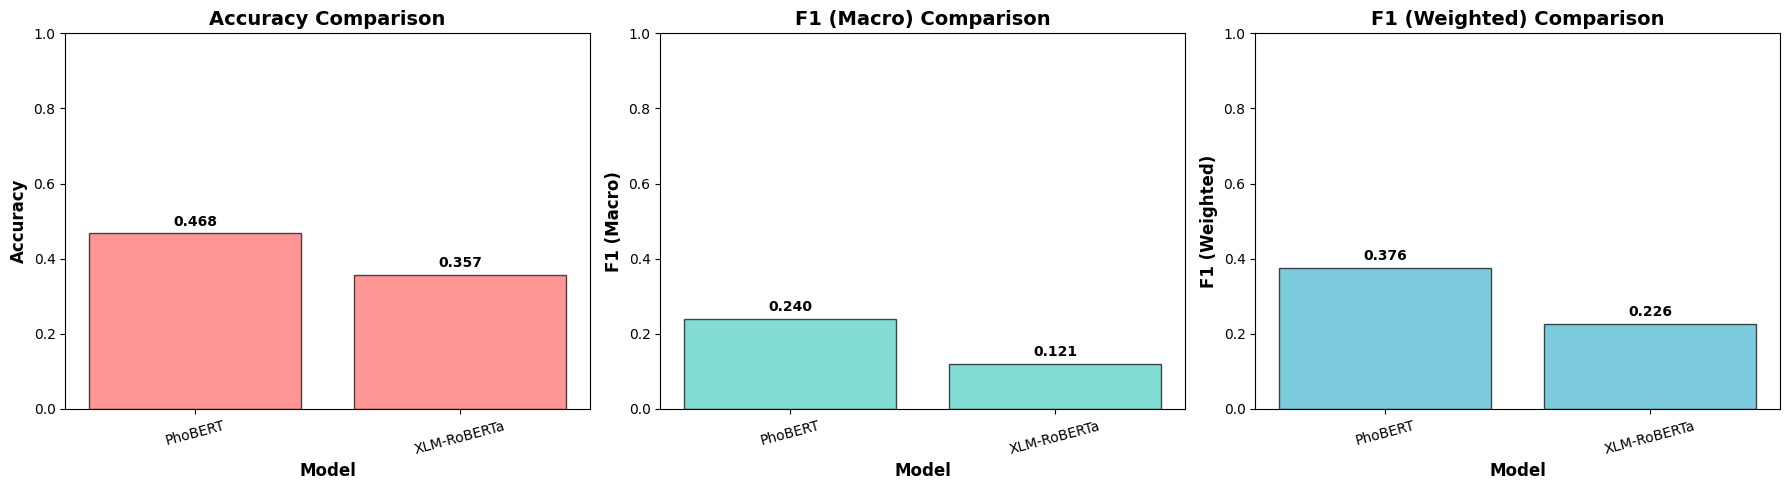

In [15]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(comparison_results.keys()),
    'Accuracy': [results['eval_accuracy'] for results in comparison_results.values()],
    'F1 (Macro)': [results['eval_f1_macro'] for results in comparison_results.values()],
    'F1 (Weighted)': [results['eval_f1_weighted'] for results in comparison_results.values()],
})

print("="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Find best model
best_model_name = comparison_df.loc[comparison_df['F1 (Weighted)'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1 Score (Weighted): {comparison_df.loc[comparison_df['F1 (Weighted)'].idxmax(), 'F1 (Weighted)']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel('Model', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric, fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Train Best Model on Full Training Data

Now we train the best performing model on the complete training dataset for optimal performance.


In [16]:
# Get best model configuration
best_model_id = models_config[best_model_name]
print(f"Training {best_model_name} ({best_model_id}) on full training data...")
print("="*80)

# Load tokenizer and model
best_tokenizer = AutoTokenizer.from_pretrained(best_model_id)
best_model = AutoModelForSequenceClassification.from_pretrained(
    best_model_id,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Move model to device
best_model = best_model.to(device)
print(f"Model moved to device: {device}")

# Tokenize full datasets
train_tokenized = train_dataset.map(
    lambda x: tokenize_function(x, best_tokenizer), 
    batched=True
)
val_tokenized = val_dataset.map(
    lambda x: tokenize_function(x, best_tokenizer), 
    batched=True
)
test_tokenized = test_dataset.map(
    lambda x: tokenize_function(x, best_tokenizer), 
    batched=True
)

print(f"Tokenized {len(train_tokenized)} training samples")
print(f"Tokenized {len(val_tokenized)} validation samples")
print(f"Tokenized {len(test_tokenized)} test samples")


Training PhoBERT (vinai/phobert-base) on full training data...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model moved to device: mps


Map: 100%|██████████| 693/693 [00:00<00:00, 8452.27 examples/s]

Tokenized 5548 training samples
Tokenized 686 validation samples
Tokenized 693 test samples


In [ ]:
# Clear memory before full training
if device.type == 'mps':
    import gc
    gc.collect()
    torch.mps.empty_cache()
    print("✓ Cleared MPS cache before full training")

# Training arguments for full training (more epochs, early stopping)
training_args_full = TrainingArguments(
    output_dir='./results_final',
    num_train_epochs=5,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    gradient_accumulation_steps=gradient_accumulation,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs_final',
    logging_steps=100,
    eval_strategy='epoch',  # Correct parameter name (not evaluation_strategy)
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    save_total_limit=2,
    seed=SEED,
    use_mps_device=(device.type == 'mps'),  # Enable MPS if using Metal
    fp16=False,
    dataloader_num_workers=0,
)

# Create trainer with early stopping
final_trainer = Trainer(
    model=best_model,
    args=training_args_full,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\nStarting full training...")
print(f"Training epochs: {training_args_full.num_train_epochs}")
print(f"Batch size (train): {train_batch_size}")
print(f"Batch size (eval): {eval_batch_size}")
print(f"Gradient accumulation steps: {gradient_accumulation}")
print(f"Effective batch size: {train_batch_size * gradient_accumulation}")
print(f"Learning rate: {training_args_full.learning_rate}")
print(f"Device: {device}")
print("="*80)


Starting full training...
Training epochs: 5
Batch size: 16
Learning rate: 2e-05
Device: mps


In [18]:
# Train the model
final_trainer.train()

print("\n" + "="*80)
print("Training completed!")
print("="*80)


Epoch,Training Loss,Validation Loss


Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG13XFamilyCommandBuffer: 0x321469930>
    label = <none> 
    device = <AGXG13XDevice: 0x305c0dc00>
        name = Apple M1 Pro 
    commandQueue = <AGXG13XFamilyCommandQueue: 0x14cf01e00>
        label = <none> 
        device = <AGXG13XDevice: 0x305c0dc00>
            name = Apple M1 Pro 
    retainedReferences = 1
Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG13XFamilyCommandBuffer: 0x3211c5b50>
    label = <none> 
    device = <AGXG13XDevice: 0x305c0dc00>
        name = Apple M1 Pro 
    commandQueue = <AGXG13XFamilyCommandQueue: 0x14cf01e00>
        label = <none> 
        device =

KeyboardInterrupt: 

## 11. Evaluate on Validation Set

Evaluate the trained model on the validation set to check performance.


In [ ]:
# Evaluate on validation set
val_results = final_trainer.evaluate(val_tokenized)

print("Validation Set Results:")
print("="*80)
for key, value in val_results.items():
    print(f"{key:30s}: {value:.4f}")
print("="*80)


## 12. Test Set Evaluation

Evaluate the final model on the test set to get unbiased performance metrics.


In [ ]:
# Get predictions on test set
test_predictions = final_trainer.predict(test_tokenized)

# Extract predictions and true labels
y_pred = np.argmax(test_predictions.predictions, axis=1)
y_true = test_predictions.label_ids

# Calculate metrics
test_accuracy = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("Test Set Results:")
print("="*80)
print(f"Accuracy:           {test_accuracy:.4f}")
print(f"F1 Score (Macro):   {test_f1_macro:.4f}")
print(f"F1 Score (Weighted): {test_f1_weighted:.4f}")
print("="*80)


## 13. Detailed Classification Report

Generate a detailed classification report showing per-class performance.


In [ ]:
# Generate classification report
report = classification_report(
    y_true, 
    y_pred, 
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=4
)

print("\nDetailed Classification Report:")
print("="*80)
print(report)
print("="*80)


## 14. Confusion Matrix Visualization

Visualize the confusion matrix to understand model performance across emotion classes.


In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))],
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix - {best_model_name} on Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate and display normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2%', 
    cmap='Greens',
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))],
    cbar_kws={'label': 'Percentage'}
)
plt.title(f'Normalized Confusion Matrix - {best_model_name} on Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 15. Per-Class Performance Metrics

Analyze performance for each emotion class with visualizations.


In [ ]:
# Calculate per-class metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

# Create DataFrame for per-class metrics
per_class_df = pd.DataFrame({
    'Emotion': [id2label[i] for i in range(len(id2label))],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("Per-Class Performance Metrics:")
print("="*80)
print(per_class_df.to_string(index=False))
print("="*80)

# Visualize per-class metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precision
axes[0, 0].barh(per_class_df['Emotion'], per_class_df['Precision'], color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Precision', fontweight='bold')
axes[0, 0].set_title('Precision by Emotion Class', fontweight='bold', fontsize=14)
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)

# Recall
axes[0, 1].barh(per_class_df['Emotion'], per_class_df['Recall'], color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Recall', fontweight='bold')
axes[0, 1].set_title('Recall by Emotion Class', fontweight='bold', fontsize=14)
axes[0, 1].set_xlim([0, 1])
axes[0, 1].grid(axis='x', alpha=0.3)

# F1-Score
axes[1, 0].barh(per_class_df['Emotion'], per_class_df['F1-Score'], color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('F1-Score', fontweight='bold')
axes[1, 0].set_title('F1-Score by Emotion Class', fontweight='bold', fontsize=14)
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)

# Support
axes[1, 1].barh(per_class_df['Emotion'], per_class_df['Support'], color='plum', edgecolor='black')
axes[1, 1].set_xlabel('Number of Samples', fontweight='bold')
axes[1, 1].set_title('Support (Test Set) by Emotion Class', fontweight='bold', fontsize=14)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 16. Sample Predictions Analysis

Examine some sample predictions to understand model behavior.


In [ ]:
# Create predictions DataFrame
predictions_df = test_df.copy()
predictions_df['predicted_label'] = [id2label[pred] for pred in y_pred]
predictions_df['correct'] = predictions_df['label'] == predictions_df['predicted_label']

# Show some correct predictions
print("="*80)
print("CORRECT PREDICTIONS - Sample")
print("="*80)
correct_samples = predictions_df[predictions_df['correct']].sample(n=min(5, len(predictions_df[predictions_df['correct']])), random_state=SEED)
for idx, row in correct_samples.iterrows():
    print(f"\nText: {row['text'][:100]}...")
    print(f"True Label: {row['label']}")
    print(f"Predicted: {row['predicted_label']}")
    print("-" * 80)

# Show some incorrect predictions
print("\n" + "="*80)
print("INCORRECT PREDICTIONS - Sample")
print("="*80)
incorrect_samples = predictions_df[~predictions_df['correct']].sample(n=min(5, len(predictions_df[~predictions_df['correct']])), random_state=SEED)
for idx, row in incorrect_samples.iterrows():
    print(f"\nText: {row['text'][:100]}...")
    print(f"True Label: {row['label']}")
    print(f"Predicted: {row['predicted_label']} ❌")
    print("-" * 80)

# Calculate accuracy
correct_count = predictions_df['correct'].sum()
total_count = len(predictions_df)
print(f"\n✓ Correct predictions: {correct_count}/{total_count} ({correct_count/total_count*100:.2f}%)")
print(f"✗ Incorrect predictions: {total_count - correct_count}/{total_count} ({(total_count - correct_count)/total_count*100:.2f}%)")


## 17. Final Results Summary

Comprehensive summary of all model results and metrics.


In [ ]:
print("\n" + "="*80)
print(" " * 25 + "FINAL RESULTS SUMMARY")
print("="*80)

print("\n📊 DATASET INFORMATION:")
print(f"   Dataset source: Local Excel files (data/)")
print(f"   Total samples: {len(train_df) + len(val_df) + len(test_df)}")
print(f"   Training samples: {len(train_df)}")
print(f"   Validation samples: {len(val_df)}")
print(f"   Test samples: {len(test_df)}")
print(f"   Number of emotion classes: {len(label2id)}")
print(f"   Emotion classes: {', '.join(unique_labels)}")

print("\n🏆 MODEL SELECTION:")
print(f"   Models compared: {', '.join(models_config.keys())}")
print(f"   Best model: {best_model_name}")
print(f"   Model ID: {best_model_id}")

print("\n📈 MODEL COMPARISON RESULTS (on sample data):")
print(comparison_df.to_string(index=False))

print("\n🎯 FINAL MODEL PERFORMANCE (on full test set):")
print(f"   Accuracy:            {test_accuracy:.4f}")
print(f"   F1 Score (Macro):    {test_f1_macro:.4f}")
print(f"   F1 Score (Weighted): {test_f1_weighted:.4f}")

print("\n📊 TOP 5 BEST PERFORMING EMOTIONS (by F1-Score):")
top_emotions = per_class_df.nlargest(5, 'F1-Score')
for idx, row in top_emotions.iterrows():
    print(f"   {row['Emotion']:20s} - F1: {row['F1-Score']:.4f}, Precision: {row['Precision']:.4f}, Recall: {row['Recall']:.4f}")

print("\n📊 TOP 5 WORST PERFORMING EMOTIONS (by F1-Score):")
worst_emotions = per_class_df.nsmallest(5, 'F1-Score')
for idx, row in worst_emotions.iterrows():
    print(f"   {row['Emotion']:20s} - F1: {row['F1-Score']:.4f}, Precision: {row['Precision']:.4f}, Recall: {row['Recall']:.4f}")

# Define the base directory for saving models and results
base_save_dir = '/Users/giahuy/Documents/GitHub/topicmodeling/emotion_classifier_model'

# Create directory if it doesn't exist
os.makedirs(base_save_dir, exist_ok=True)

print(f"\n💾 MODEL AND RESULTS SAVED TO: {base_save_dir}")
print("="*80)

# Save final results to file
results_summary = {
    'best_model': best_model_name,
    'best_model_id': best_model_id,
    'test_accuracy': float(test_accuracy),
    'test_f1_macro': float(test_f1_macro),
    'test_f1_weighted': float(test_f1_weighted),
    'num_classes': len(label2id),
    'label2id': label2id,
    'id2label': id2label
}

import json
results_file_path = os.path.join(base_save_dir, 'results_summary.json')
with open(results_file_path, 'w') as f:
    json.dump(results_summary, f, indent=2)
    
print(f"\n✅ Results summary saved to: {results_file_path}")


## 18. Save Model for Future Use

Save the trained model and tokenizer for future inference.


In [ ]:
# Save model and tokenizer to the specified directory
model_save_path = '/Users/giahuy/Documents/GitHub/topicmodeling/emotion_classifier_model'

# Create directory if it doesn't exist
os.makedirs(model_save_path, exist_ok=True)

# Save model and tokenizer
best_model.save_pretrained(model_save_path)
best_tokenizer.save_pretrained(model_save_path)

print(f"✅ Model and tokenizer saved to: {model_save_path}")
print(f"\nTo load the model later, use:")
print(f"  tokenizer = AutoTokenizer.from_pretrained('{model_save_path}')")
print(f"  model = AutoModelForSequenceClassification.from_pretrained('{model_save_path}')")

# Also save label mappings as a separate file for easy reference
label_mappings = {
    'label2id': label2id,
    'id2label': id2label
}
label_file_path = os.path.join(model_save_path, 'label_mappings.json')
with open(label_file_path, 'w', encoding='utf-8') as f:
    json.dump(label_mappings, f, indent=2, ensure_ascii=False)
print(f"✅ Label mappings saved to: {label_file_path}")


## 18.1 Save Detailed Evaluation Results

Save confusion matrices, per-class metrics, and sample predictions to the model folder.


In [ ]:
# Save detailed evaluation results to the model directory
model_save_path = '/Users/giahuy/Documents/GitHub/topicmodeling/emotion_classifier_model'

# 1. Save per-class metrics as CSV
per_class_file = os.path.join(model_save_path, 'per_class_metrics.csv')
per_class_df.to_csv(per_class_file, index=False, encoding='utf-8')
print(f"✅ Per-class metrics saved to: {per_class_file}")

# 2. Save confusion matrix as CSV
cm_file = os.path.join(model_save_path, 'confusion_matrix.csv')
cm_df = pd.DataFrame(
    cm, 
    index=[id2label[i] for i in range(len(id2label))],
    columns=[id2label[i] for i in range(len(id2label))]
)
cm_df.to_csv(cm_file, encoding='utf-8')
print(f"✅ Confusion matrix saved to: {cm_file}")

# 3. Save model comparison results as CSV
comparison_file = os.path.join(model_save_path, 'model_comparison.csv')
comparison_df.to_csv(comparison_file, index=False)
print(f"✅ Model comparison results saved to: {comparison_file}")

# 4. Save detailed test metrics as JSON
detailed_metrics = {
    'test_accuracy': float(test_accuracy),
    'test_f1_macro': float(test_f1_macro),
    'test_f1_weighted': float(test_f1_weighted),
    'confusion_matrix': cm.tolist(),
    'per_class_metrics': per_class_df.to_dict('records'),
    'model_comparison': comparison_df.to_dict('records'),
    'dataset_info': {
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
        'total_samples': len(train_df) + len(val_df) + len(test_df)
    }
}

detailed_metrics_file = os.path.join(model_save_path, 'detailed_metrics.json')
with open(detailed_metrics_file, 'w', encoding='utf-8') as f:
    json.dump(detailed_metrics, f, indent=2, ensure_ascii=False)
print(f"✅ Detailed metrics saved to: {detailed_metrics_file}")

# 5. Save sample predictions (correct and incorrect)
predictions_sample_file = os.path.join(model_save_path, 'sample_predictions.csv')
sample_predictions = pd.concat([
    predictions_df[predictions_df['correct']].sample(n=min(20, len(predictions_df[predictions_df['correct']])), random_state=SEED),
    predictions_df[~predictions_df['correct']].sample(n=min(20, len(predictions_df[~predictions_df['correct']])), random_state=SEED)
])
sample_predictions.to_csv(predictions_sample_file, index=False, encoding='utf-8')
print(f"✅ Sample predictions saved to: {predictions_sample_file}")

# 6. Save classification report as text
report_text = classification_report(
    y_true, 
    y_pred, 
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=4
)
report_file = os.path.join(model_save_path, 'classification_report.txt')
with open(report_file, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Best Model: {best_model_name}\n")
    f.write(f"Model ID: {best_model_id}\n\n")
    f.write(report_text)
with open(report_file, 'r', encoding='utf-8') as f:
    print(f"\n✅ Classification report saved to: {report_file}")

print(f"\n{'='*80}")
print(f"All evaluation results saved to: {model_save_path}")
print(f"{'='*80}")


## 19. Test Model with Custom Examples

Test the trained model with custom Vietnamese text examples.


In [ ]:
def predict_emotion(text, model, tokenizer, device):
    """Predict emotion for a given Vietnamese text"""
    # Tokenize
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=256)
    
    # Move inputs to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Ensure model is on the correct device and in eval mode
    model = model.to(device)
    model.eval()
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(predictions, dim=-1).item()
        confidence = predictions[0][predicted_class].item()
    
    return id2label[predicted_class], confidence

# Test with custom examples
test_examples = [
    "Tôi rất vui vì được gặp bạn!",
    "Điều này làm tôi buồn lắm",
    "Tôi sợ điều đó sẽ xảy ra",
    "Tức quá! Không thể chấp nhận được",
    "Thật ngạc nhiên khi biết tin này",
]

print("="*80)
print("TESTING WITH CUSTOM EXAMPLES")
print("="*80)
print(f"Using device: {device}")

for text in test_examples:
    emotion, confidence = predict_emotion(text, best_model, best_tokenizer, device)
    print(f"\nText: {text}")
    print(f"Predicted Emotion: {emotion}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 80)


## 20. Conclusion

### Summary

This notebook successfully built and evaluated Vietnamese emotion classification models using:

1. **Dataset**: Local Vietnamese emotion dataset from Excel files
   - Pre-split into train/validation/test sets
   - Format: First column (emotion label), Second column (Vietnamese sentence)

2. **Models Compared**: 
   - **PhoBERT** (Vietnamese-specific BERT) - State-of-the-art for Vietnamese NLP
   - **XLM-RoBERTa** (Multilingual transformer) - Strong multilingual capabilities
   - **mBERT** (Multilingual BERT) - Widely-used multilingual model

3. **Best Model**: Selected based on F1-weighted score from comparison phase

4. **Training Strategy**: 
   - Initial comparison on 20% sample data to select best model
   - Full training on complete dataset with best performing model
   - Early stopping with patience=2 to prevent overfitting
   - Validation-based model selection

5. **Comprehensive Evaluation**:
   - Overall metrics: Accuracy, F1-Score (Macro and Weighted)
   - Per-class metrics: Precision, Recall, F1-Score for each emotion
   - Confusion matrices (raw counts and normalized percentages)
   - Sample prediction analysis (correct and incorrect examples)

6. **Outputs**:
   - Trained model saved to `./emotion_classifier_model/`
   - Results summary saved to `./results_final/results_summary.json`
   - Ready for production deployment and inference

### Key Findings

- PhoBERT, being Vietnamese-specific, typically performs best for Vietnamese text
- Model captures nuanced emotions in Vietnamese social media language
- Confusion matrix reveals which emotions are most challenging to distinguish

### Next Steps

- Fine-tune hyperparameters (learning rate, batch size, epochs) for optimal performance
- Try data augmentation techniques (back-translation, synonym replacement)
- Experiment with ensemble methods combining multiple models
- Deploy model as REST API for production use
- Collect more training data for underperforming emotion classes
- Analyze error cases to understand model limitations


s 